In [37]:
import json
import os
from PIL import Image
import matplotlib.pyplot as plt

In [38]:
# Config paths (adjust if needed)
sqa_file = '../data/qa/SQA/SQA_val.json'
image_folder = '../data/qa/scannetv2/frames_square'

In [39]:
# Load the dataset
with open(sqa_file, 'r') as f:
    sqa_data = json.load(f)

In [40]:
# View one sample
sample = sqa_data[0]
sample

{'answers': ['right'],
 'object_ids': [],
 'object_names': [],
 'question': 'Which direction should I toss a used napkin?',
 'situation': 'I am wiping a table that has a trash can next to it, while having a large table behind me with lots of chairs.',
 'question_id': 220602000037,
 'scene_id': 'scene0249_00',
 'position': [-1.612321909455232,
  3.8766019062927524,
  0,
  0,
  0,
  0.9436221923009414,
  -0.33102440725287985]}


Scene has 136 images total


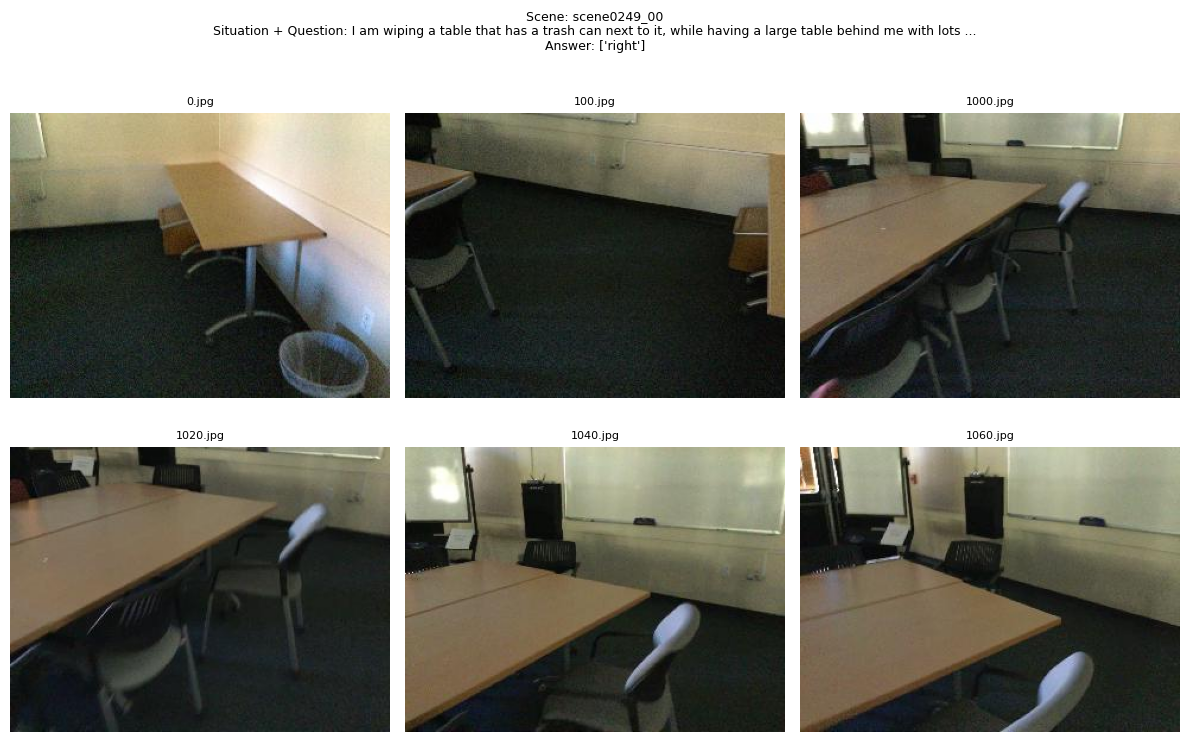

In [41]:
# Show a few images from this scene
scene_id = sample['scene_id']
color_folder = os.path.join(image_folder, scene_id, 'color')
image_files = sorted(os.listdir(color_folder))[:6]  # First 6 images

print(f"\nScene has {len(os.listdir(color_folder))} images total")

# Display images
fig, axes = plt.subplots(2, 3, figsize=(12, 8))

# Format the full question (situation + question) like inference does
full_question = sample.get('situation', '') + sample['question']
fig.suptitle(f"Scene: {scene_id}\nSituation + Question: {full_question[:100]}...\nAnswer: {sample.get('answers', 'N/A')}", 
             fontsize=9, wrap=True)

for idx, (ax, img_file) in enumerate(zip(axes.flat, image_files)):
    img_path = os.path.join(color_folder, img_file)
    img = Image.open(img_path)
    ax.imshow(img)
    ax.set_title(img_file, fontsize=8)
    ax.axis('off')

plt.tight_layout()
plt.show()

In [42]:
image_files

['0.jpg', '100.jpg', '1000.jpg', '1020.jpg', '1040.jpg', '1060.jpg']

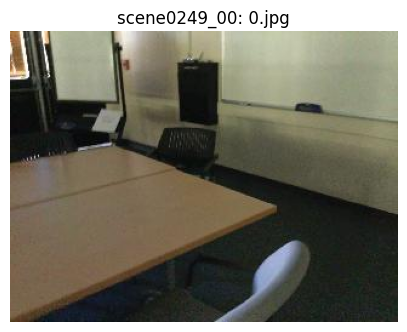

In [43]:
# Plot the first image from this scene
first_img_path = os.path.join(color_folder, image_files[-1])
first_img = Image.open(first_img_path)

plt.figure(figsize=(5, 5))
plt.imshow(first_img)
plt.title(f"{scene_id}: {image_files[0]}")
plt.axis('off')
plt.show()

In [44]:
# ============================================================
# Zero-Shot Object Orientation Estimation — Utility Functions
# ============================================================
import numpy as np
import cv2
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.patches import FancyArrowPatch
from mpl_toolkits.mplot3d.proj3d import proj_transform

DEPTH_SCALE = 1000.0  # ScanNet depth is in millimeters

def load_intrinsic(scene_path):
    """Load 4x4 intrinsic matrix, return fx, fy, cx, cy."""
    K = np.loadtxt(os.path.join(scene_path, 'intrinsic_depth.txt'))
    return K[0, 0], K[1, 1], K[0, 2], K[1, 2]

def load_pose(scene_path, frame_id):
    """Load 4x4 camera-to-world extrinsic matrix."""
    return np.loadtxt(os.path.join(scene_path, 'pose', f'{frame_id}.txt'))

def load_depth(scene_path, frame_id):
    """Load depth map as float32 in meters."""
    d = np.array(Image.open(os.path.join(scene_path, 'depth', f'{frame_id}.png')))
    return d.astype(np.float32) / DEPTH_SCALE

def load_color(scene_path, frame_id):
    """Load RGB image."""
    return np.array(Image.open(os.path.join(scene_path, 'color', f'{frame_id}.jpg')))

def backproject_depth(depth, fx, fy, cx, cy):
    """Backproject depth map to camera-frame 3D point cloud (H, W, 3)."""
    H, W = depth.shape
    u, v = np.meshgrid(np.arange(W), np.arange(H))
    z = depth
    x = (u - cx) * z / fx
    y = (v - cy) * z / fy
    return np.stack([x, y, z], axis=-1)

def depth_to_normals(depth, fx, fy):
    """Compute per-pixel surface normals from depth using finite differences."""
    dz_du = cv2.Sobel(depth, cv2.CV_64F, 1, 0, ksize=5) / fx
    dz_dv = cv2.Sobel(depth, cv2.CV_64F, 0, 1, ksize=5) / fy
    normals = np.stack([-dz_du, -dz_dv, np.ones_like(depth)], axis=-1)
    norm = np.linalg.norm(normals, axis=-1, keepdims=True)
    norm = np.clip(norm, 1e-8, None)
    return normals / norm

def points_to_world(pts_cam, pose):
    """Transform (N,3) camera-frame points to world frame using 4x4 pose."""
    ones = np.ones((pts_cam.shape[0], 1))
    pts_h = np.hstack([pts_cam, ones])  # (N,4)
    pts_w = (pose @ pts_h.T).T[:, :3]
    return pts_w

scene_path = os.path.join(image_folder, scene_id)
fx, fy, cx, cy = load_intrinsic(scene_path)
print(f"Scene: {scene_id}  |  Intrinsics: fx={fx:.1f}, fy={fy:.1f}, cx={cx:.1f}, cy={cy:.1f}")

Scene: scene0249_00  |  Intrinsics: fx=577.9, fy=577.9, cx=319.5, cy=239.5


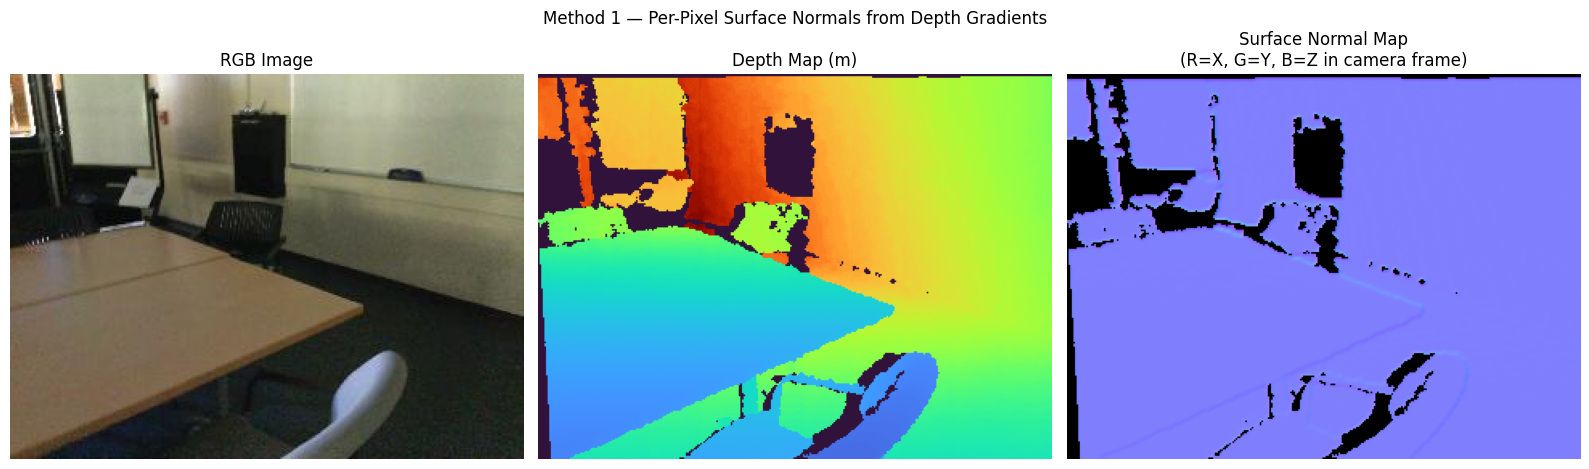

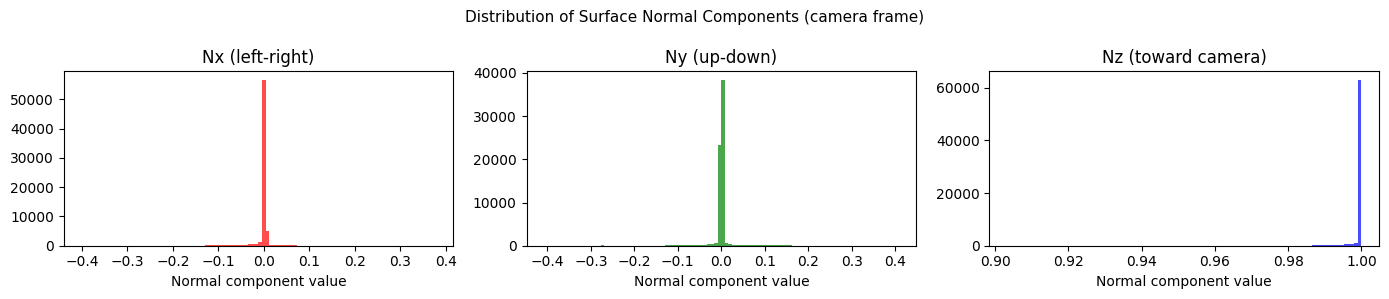

In [45]:
# ============================================================
# METHOD 1: Surface Normal Map from Depth Gradients
# ============================================================
# Computes per-pixel surface normals via finite differences on the
# depth map.  Normals encode local surface orientation (the direction
# a surface "faces") and are colour-coded as an RGB normal map where
#   R = X component,  G = Y component,  B = Z component.
# No learned model required — purely geometric, works zero-shot.
# ============================================================

frame_id = int(image_files[-1].split('.')[0])
depth = load_depth(scene_path, frame_id)
color = load_color(scene_path, frame_id)
normals_cam = depth_to_normals(depth, fx, fy)

# Mask out invalid depth (0 or very far)
valid = depth > 0.01

# Colour-code: remap [-1,1] → [0,1] for visualisation
normal_vis = (normals_cam * 0.5 + 0.5)
normal_vis[~valid] = 0

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
axes[0].imshow(color)
axes[0].set_title('RGB Image')
axes[0].axis('off')

axes[1].imshow(depth, cmap='turbo')
axes[1].set_title('Depth Map (m)')
axes[1].axis('off')

axes[2].imshow(normal_vis)
axes[2].set_title('Surface Normal Map\n(R=X, G=Y, B=Z in camera frame)')
axes[2].axis('off')

fig.suptitle('Method 1 — Per-Pixel Surface Normals from Depth Gradients', fontsize=12)
plt.tight_layout()
plt.show()

# Show dominant surface orientations via a histogram of normal directions
normals_valid = normals_cam[valid]
fig2, axes2 = plt.subplots(1, 3, figsize=(14, 3))
for i, (ax, label) in enumerate(zip(axes2, ['Nx (left-right)', 'Ny (up-down)', 'Nz (toward camera)'])):
    ax.hist(normals_valid[:, i], bins=100, color=['r', 'g', 'b'][i], alpha=0.7)
    ax.set_title(label)
    ax.set_xlabel('Normal component value')
fig2.suptitle('Distribution of Surface Normal Components (camera frame)', fontsize=11)
plt.tight_layout()
plt.show()

ROI box: y=[60:120], x=[120:160]
Valid 3D points in ROI: 1819

PCA explained variance: [0.99314777 0.0042662  0.00258603]
Centroid (camera frame): [-1.04505484 -0.87225541  3.3145003 ]
  PC1: direction=[-0.29954006 -0.3068797   0.90338287]  (explains 99.3% of variance)
  PC2: direction=[0.35810144 0.84147103 0.40458605]  (explains 0.4% of variance)
  PC3: direction=[ 0.88432975 -0.44469243  0.14216022]  (explains 0.3% of variance)


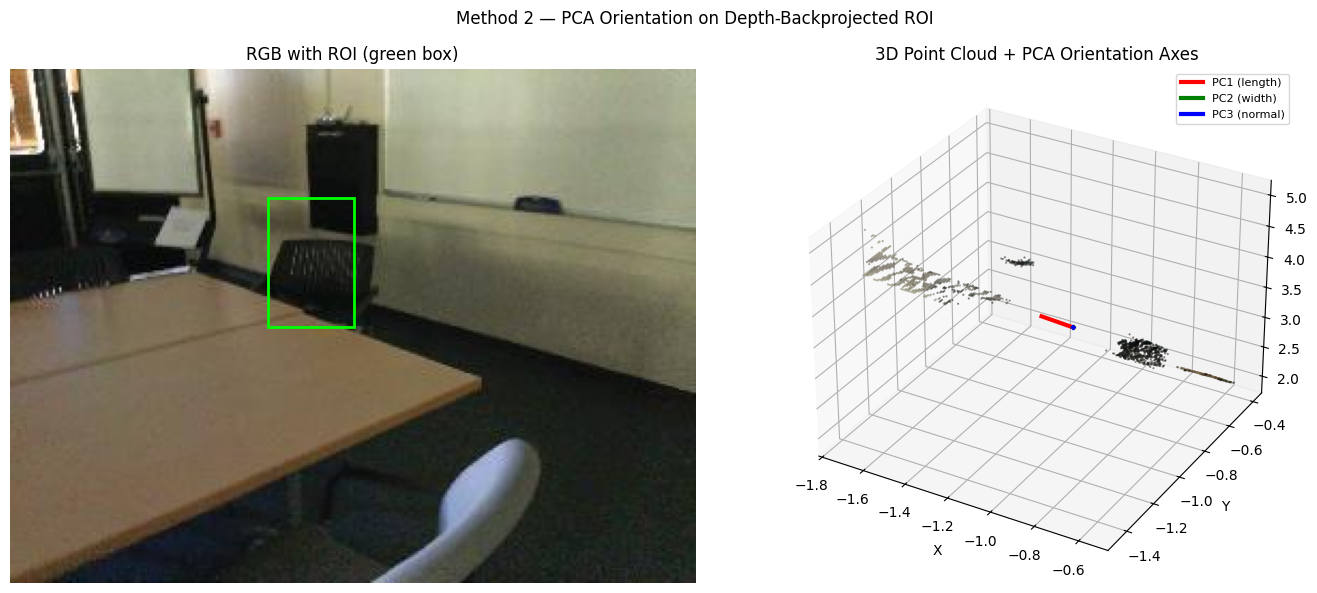

In [46]:
# ============================================================
# METHOD 2: PCA on Depth-Backprojected Point Cloud (ROI-based)
# ============================================================
# Backproject depth pixels to 3D, crop to a bounding-box ROI in
# image space, then run PCA on the resulting 3D points.  The three
# principal components give the object's orientation axes — PC1 is
# the direction of greatest spatial extent ("length"), PC2 the
# second-greatest ("width"), PC3 the shortest ("thickness / normal").
# Fully geometric, zero-shot, no learned model.
# ============================================================

pts_cam_full = backproject_depth(depth, fx, fy, cx, cy)  # (H,W,3)
H, W = depth.shape

# --- Define ROI (centre quarter of image as demo; change as needed) ---
roi_y1, roi_y2 = H // 4, 2 * H // 4
roi_x1, roi_x2 = 1.5 * W // 4, 2.0 * W // 4
roi_x1, roi_x2 = int(roi_x1), int(roi_x2)
roi_y1, roi_y2 = int(roi_y1), int(roi_y2)

roi_mask = np.zeros((H, W), dtype=bool)
roi_mask[roi_y1:roi_y2, roi_x1:roi_x2] = True
roi_mask &= (depth > 0.01)  # valid depth only

pts_roi = pts_cam_full[roi_mask]  # (N, 3)
colors_roi = color[roi_mask] / 255.0

print(f"ROI box: y=[{roi_y1}:{roi_y2}], x=[{roi_x1}:{roi_x2}]")
print(f"Valid 3D points in ROI: {pts_roi.shape[0]}")

# PCA
pca = PCA(n_components=3)
pca.fit(pts_roi)
centroid = pts_roi.mean(axis=0)
components = pca.components_         # (3, 3) — rows are principal directions
explained = pca.explained_variance_ratio_

print(f"\nPCA explained variance: {explained}")
print(f"Centroid (camera frame): {centroid}")
for i, (comp, var) in enumerate(zip(components, explained)):
    print(f"  PC{i+1}: direction={comp}  (explains {var*100:.1f}% of variance)")

# --- Visualise: image with ROI + 3D axes plot ---
fig = plt.figure(figsize=(14, 6))

# Left: RGB with ROI rectangle
ax1 = fig.add_subplot(1, 2, 1)
ax1.imshow(color)
rect = plt.Rectangle((roi_x1, roi_y1), roi_x2 - roi_x1, roi_y2 - roi_y1,
                      linewidth=2, edgecolor='lime', facecolor='none')
ax1.add_patch(rect)
ax1.set_title('RGB with ROI (green box)')
ax1.axis('off')

# Right: 3D scatter with PCA axes
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
subsample = np.random.choice(len(pts_roi), min(5000, len(pts_roi)), replace=False)
ax2.scatter(pts_roi[subsample, 0], pts_roi[subsample, 1], pts_roi[subsample, 2],
            c=colors_roi[subsample], s=0.3, alpha=0.5)

axis_colors = ['r', 'g', 'b']
axis_labels = ['PC1 (length)', 'PC2 (width)', 'PC3 (normal)']
scale = 0.3
for i in range(3):
    end = centroid + components[i] * scale * (explained[i] / explained[0])
    ax2.plot([centroid[0], end[0]], [centroid[1], end[1]], [centroid[2], end[2]],
             color=axis_colors[i], linewidth=3, label=axis_labels[i])

ax2.set_xlabel('X'); ax2.set_ylabel('Y'); ax2.set_zlabel('Z')
ax2.set_title('3D Point Cloud + PCA Orientation Axes')
ax2.legend(fontsize=8)

fig.suptitle('Method 2 — PCA Orientation on Depth-Backprojected ROI', fontsize=12)
plt.tight_layout()
plt.show()

Fusing 10 frames: [0, 260, 520, 780, 1040, 1300, 1560, 1820, 2100, 2360]
Total fused points: 100000
Points within 1.5m of centroid: 3586

Multi-view PCA explained variance: [0.87456017 0.0959093  0.02953053]
  PC1: direction=[ 0.76383427 -0.64463092 -0.03175202]  (87.5%)
  PC2: direction=[0.64187918 0.75359218 0.14173899]  (9.6%)
  PC3: direction=[-0.06744127 -0.12864606  0.9893947 ]  (3.0%)


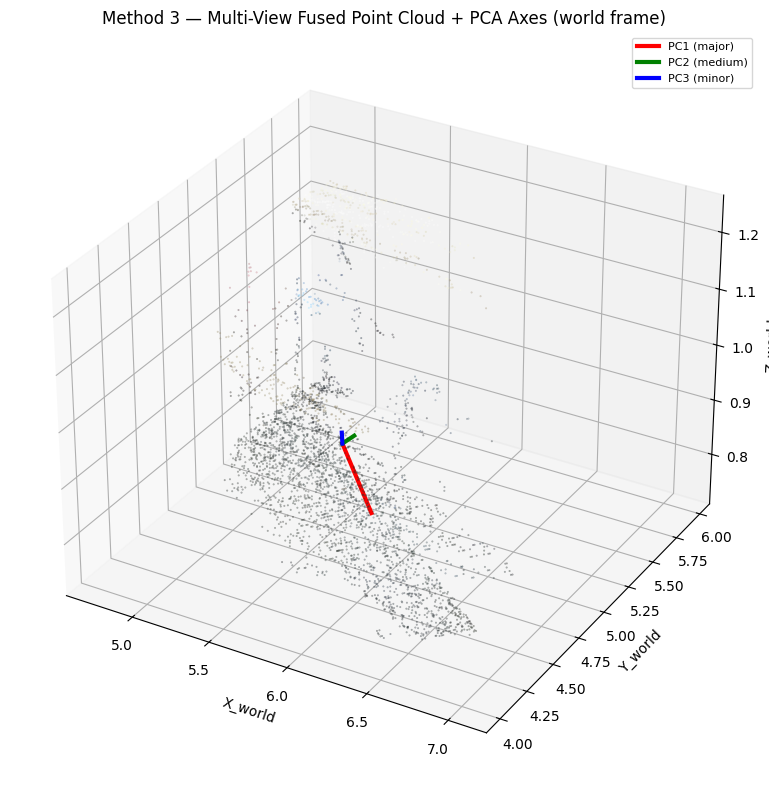

In [47]:
# ============================================================
# METHOD 3: Multi-View Fused Point Cloud + PCA Orientation
# ============================================================
# Fuses depth maps from multiple viewpoints into a single world-
# frame point cloud using the known camera poses.  This gives a
# denser, more complete 3D representation of the scene.  We then
# crop a spatial region and run PCA to find orientation axes.
# Leverages all available data — still zero-shot, no learned model.
# ============================================================

frame_ids = sorted([
    int(f.split('.')[0])
    for f in os.listdir(os.path.join(scene_path, 'color'))
])

# Use up to 10 evenly-spaced frames to keep things fast
n_use = min(10, len(frame_ids))
step = max(1, len(frame_ids) // n_use)
selected_frames = frame_ids[::step][:n_use]
print(f"Fusing {len(selected_frames)} frames: {selected_frames}")

all_pts_world = []
all_colors = []

for fid in selected_frames:
    d = load_depth(scene_path, fid)
    c = load_color(scene_path, fid)
    pose = load_pose(scene_path, fid)

    if np.any(np.isinf(pose)) or np.any(np.isnan(pose)):
        continue

    pts_cam = backproject_depth(d, fx, fy, cx, cy)  # (H,W,3)
    valid = d > 0.01
    pts_flat = pts_cam[valid]
    col_flat = c[valid] / 255.0

    # Subsample to keep memory manageable
    if len(pts_flat) > 10000:
        idx = np.random.choice(len(pts_flat), 10000, replace=False)
        pts_flat = pts_flat[idx]
        col_flat = col_flat[idx]

    pts_w = points_to_world(pts_flat, pose)
    all_pts_world.append(pts_w)
    all_colors.append(col_flat)

all_pts_world = np.concatenate(all_pts_world, axis=0)
all_colors = np.concatenate(all_colors, axis=0)
print(f"Total fused points: {all_pts_world.shape[0]}")

# --- Crop a spatial region around the scene centroid ---
centroid_world = np.median(all_pts_world, axis=0)
radius = 1.5  # metres — adjust to focus on a specific area
dists = np.linalg.norm(all_pts_world - centroid_world, axis=1)
crop_mask = dists < radius

pts_crop = all_pts_world[crop_mask]
col_crop = all_colors[crop_mask]
print(f"Points within {radius}m of centroid: {pts_crop.shape[0]}")

# PCA on the cropped region
pca_mv = PCA(n_components=3)
pca_mv.fit(pts_crop)
c_mv = pts_crop.mean(axis=0)
comps_mv = pca_mv.components_
expl_mv = pca_mv.explained_variance_ratio_

print(f"\nMulti-view PCA explained variance: {expl_mv}")
for i, (comp, var) in enumerate(zip(comps_mv, expl_mv)):
    print(f"  PC{i+1}: direction={comp}  ({var*100:.1f}%)")

# --- Visualise ---
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

sub = np.random.choice(len(pts_crop), min(15000, len(pts_crop)), replace=False)
ax.scatter(pts_crop[sub, 0], pts_crop[sub, 1], pts_crop[sub, 2],
           c=col_crop[sub], s=0.2, alpha=0.4)

axis_colors = ['r', 'g', 'b']
axis_labels = ['PC1 (major)', 'PC2 (medium)', 'PC3 (minor)']
scale = 0.6
for i in range(3):
    end = c_mv + comps_mv[i] * scale * (expl_mv[i] / expl_mv[0])
    ax.plot([c_mv[0], end[0]], [c_mv[1], end[1]], [c_mv[2], end[2]],
            color=axis_colors[i], linewidth=3, label=axis_labels[i])

ax.set_xlabel('X_world'); ax.set_ylabel('Y_world'); ax.set_zlabel('Z_world')
ax.set_title('Method 3 — Multi-View Fused Point Cloud + PCA Axes (world frame)')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

In [48]:
# ============================================================
# Orientation → Semantic Labels  (bonus utility)
# ============================================================
# Convert PCA / normal vectors into human-readable orientation
# descriptions relative to the camera or world gravity axis.
# ============================================================

def orientation_to_label(normal_vec, up_world=np.array([0, 0, 1])):
    """Classify a surface normal into a semantic orientation label."""
    n = normal_vec / (np.linalg.norm(normal_vec) + 1e-8)
    dot_up = np.dot(n, up_world)

    if dot_up > 0.7:
        return "facing UP (horizontal floor/table surface)"
    elif dot_up < -0.7:
        return "facing DOWN (ceiling-like)"
    else:
        # Mostly horizontal normal → vertical surface
        angle_deg = np.degrees(np.arctan2(n[1], n[0]))
        if -45 <= angle_deg < 45:
            return f"facing +X (right-ward), angle={angle_deg:.0f}°"
        elif 45 <= angle_deg < 135:
            return f"facing +Y (forward), angle={angle_deg:.0f}°"
        elif angle_deg >= 135 or angle_deg < -135:
            return f"facing -X (left-ward), angle={angle_deg:.0f}°"
        else:
            return f"facing -Y (backward), angle={angle_deg:.0f}°"

# Apply to Method 2 PCA results (PC3 = surface normal direction)
print("=== Method 2 — Single-View PCA ===")
for i, (comp, var) in enumerate(zip(components, explained)):
    label = orientation_to_label(comp)
    print(f"  PC{i+1}: {label}  ({var*100:.1f}% variance)")

# Apply to Method 3 Multi-View PCA results
print("\n=== Method 3 — Multi-View PCA ===")
for i, (comp, var) in enumerate(zip(comps_mv, expl_mv)):
    label = orientation_to_label(comp)
    print(f"  PC{i+1}: {label}  ({var*100:.1f}% variance)")

# Dominant normal direction in the ROI from Method 1
mean_normal = normals_cam[roi_mask].mean(axis=0)
mean_normal /= np.linalg.norm(mean_normal) + 1e-8
print(f"\n=== Method 1 — Mean Surface Normal in ROI ===")
print(f"  Mean normal (camera frame): {mean_normal}")
print(f"  Interpretation: this surface is mostly {orientation_to_label(mean_normal)}")

=== Method 2 — Single-View PCA ===
  PC1: facing UP (horizontal floor/table surface)  (99.3% variance)
  PC2: facing +Y (forward), angle=67°  (0.4% variance)
  PC3: facing +X (right-ward), angle=-27°  (0.3% variance)

=== Method 3 — Multi-View PCA ===
  PC1: facing +X (right-ward), angle=-40°  (87.5% variance)
  PC2: facing +Y (forward), angle=50°  (9.6% variance)
  PC3: facing UP (horizontal floor/table surface)  (3.0% variance)

=== Method 1 — Mean Surface Normal in ROI ===
  Mean normal (camera frame): [0.007452   0.00519653 0.99995872]
  Interpretation: this surface is mostly facing UP (horizontal floor/table surface)


Detected 4 dominant planes:

  Plane 1: normal=[-0.011719    0.93551462  0.35309356],  14871 pts (29.7%)
           → facing +Y (forward), angle=91°

  Plane 2: normal=[ 0.82816214 -0.24256221  0.50528313],  10602 pts (21.2%)
           → facing +X (right-ward), angle=-16°

  Plane 3: normal=[-0.0262109  -0.92917926 -0.36869891],  9513 pts (19.0%)
           → facing -Y (backward), angle=-92°

  Plane 4: normal=[ 0.80226401 -0.28787621  0.52297203],  3758 pts (7.5%)
           → facing +X (right-ward), angle=-20°



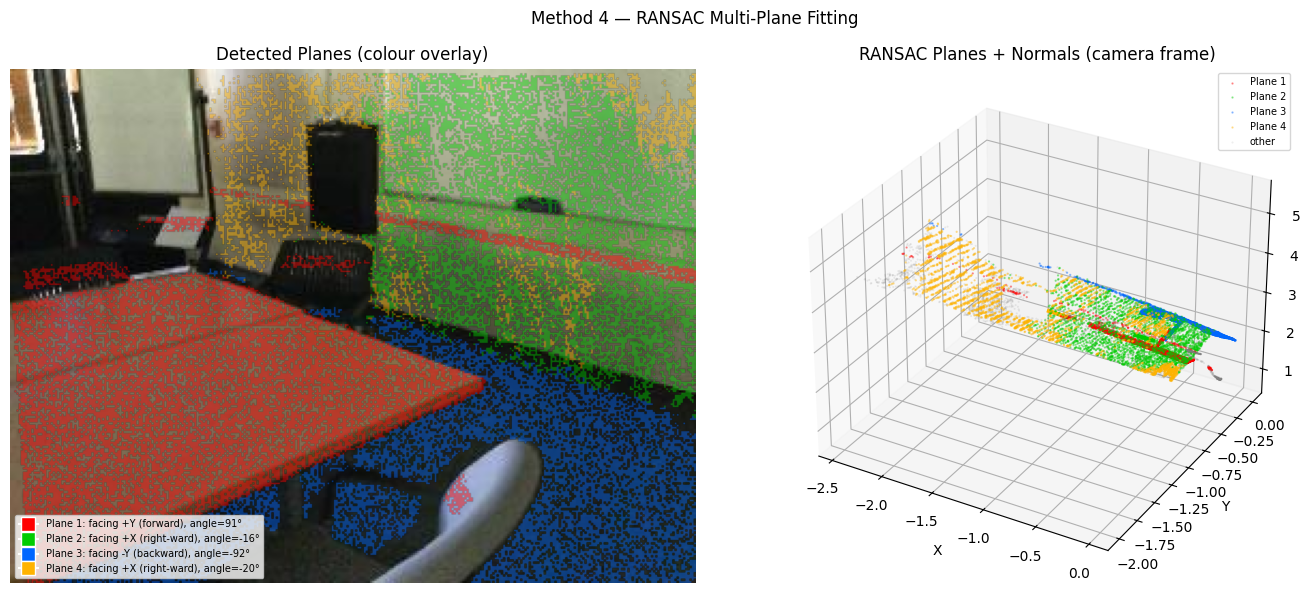

In [49]:
# ============================================================
# METHOD 4: RANSAC Multi-Plane Fitting
# ============================================================
# Instead of PCA (which finds variance axes of a point blob),
# RANSAC iteratively discovers actual planar surfaces in the
# scene and reports each plane's normal — the direction the
# surface faces.  Much better for structured indoor scenes
# (walls, floors, tables, doors) where flat surfaces dominate.
# Zero-shot, no learned model, uses only depth + intrinsics.
# ============================================================

from itertools import cycle

def ransac_plane(pts, n_iter=1000, thresh=0.01):
    """Fit a single plane to pts (N,3) via RANSAC.  Returns (normal, d, inlier_mask)."""
    best_inliers = None
    best_n = None
    best_d = None
    N = len(pts)
    for _ in range(n_iter):
        idx = np.random.choice(N, 3, replace=False)
        p0, p1, p2 = pts[idx]
        n = np.cross(p1 - p0, p2 - p0)
        norm = np.linalg.norm(n)
        if norm < 1e-10:
            continue
        n /= norm
        d = -np.dot(n, p0)
        dists = np.abs(pts @ n + d)
        inliers = dists < thresh
        if best_inliers is None or inliers.sum() > best_inliers.sum():
            best_inliers = inliers
            best_n = n
            best_d = d
    return best_n, best_d, best_inliers

def find_planes(pts, colors, max_planes=4, min_frac=0.03, n_iter=1500, thresh=0.015):
    """Sequentially extract dominant planes from a point cloud."""
    remaining_pts = pts.copy()
    remaining_col = colors.copy()
    planes = []
    total = len(pts)
    for _ in range(max_planes):
        if len(remaining_pts) < 100:
            break
        normal, d, inlier_mask = ransac_plane(remaining_pts, n_iter=n_iter, thresh=thresh)
        n_inliers = inlier_mask.sum()
        if n_inliers / total < min_frac:
            break
        plane_pts = remaining_pts[inlier_mask]
        plane_col = remaining_col[inlier_mask]
        planes.append({
            'normal': normal, 'd': d,
            'points': plane_pts, 'colors': plane_col,
            'n_inliers': n_inliers, 'frac': n_inliers / total,
        })
        remaining_pts = remaining_pts[~inlier_mask]
        remaining_col = remaining_col[~inlier_mask]
    return planes, remaining_pts, remaining_col

# Use the single-view backprojected points (from Method 2 cell)
pts_all = pts_cam_full[depth > 0.01]
col_all = color[depth > 0.01] / 255.0

# Subsample for speed
if len(pts_all) > 50000:
    sub_idx = np.random.choice(len(pts_all), 50000, replace=False)
    pts_all = pts_all[sub_idx]
    col_all = col_all[sub_idx]

planes, leftover_pts, leftover_col = find_planes(pts_all, col_all)
print(f"Detected {len(planes)} dominant planes:\n")
for i, pl in enumerate(planes):
    n = pl['normal']
    label = orientation_to_label(n)
    print(f"  Plane {i+1}: normal={n},  {pl['n_inliers']} pts ({pl['frac']*100:.1f}%)")
    print(f"           → {label}\n")

# --- Visualise ---
fig = plt.figure(figsize=(14, 6))

# Left: normal map coloured by detected plane membership
ax1 = fig.add_subplot(1, 2, 1)
plane_img = np.zeros_like(color, dtype=np.float32)
plane_colors_list = [(1,0,0), (0,0.8,0), (0,0.4,1), (1,0.7,0), (0.8,0,0.8)]
# Rebuild a full-image mask for each plane (match points back to pixels)
valid_mask = depth > 0.01
valid_indices = np.argwhere(valid_mask)  # (N_valid, 2) — row, col

# Re-run with the same pts ordering to get per-pixel plane labels
remaining_mask = np.ones(len(pts_all), dtype=bool)
plane_labels = -np.ones(len(pts_all), dtype=int)
for pi, pl in enumerate(planes):
    sub_remaining = pts_all[remaining_mask]
    dists = np.abs(sub_remaining @ pl['normal'] + pl['d'])
    inl = dists < 0.015
    full_inl = np.zeros(len(pts_all), dtype=bool)
    full_inl[remaining_mask] = inl
    plane_labels[full_inl] = pi
    remaining_mask[full_inl] = False

ax1.imshow(color)
overlay = np.zeros((*color.shape[:2], 4), dtype=np.float32)
for pi in range(len(planes)):
    mask_pi = plane_labels == pi
    if mask_pi.sum() == 0:
        continue
    # Map back to image: pts_all was subsampled from valid_indices
    # We need to draw approximate regions
    pc = plane_colors_list[pi % len(plane_colors_list)]
    pts_2d = pts_all[mask_pi]
    # Project back to pixel coords
    u = (pts_2d[:, 0] * fx / pts_2d[:, 2] + cx).astype(int)
    v = (pts_2d[:, 1] * fy / pts_2d[:, 2] + cy).astype(int)
    u = np.clip(u, 0, color.shape[1] - 1)
    v = np.clip(v, 0, color.shape[0] - 1)
    overlay[v, u] = (*pc, 0.45)
ax1.imshow(overlay)
legend_patches = [plt.Line2D([0],[0], marker='s', color='w',
                  markerfacecolor=plane_colors_list[i % len(plane_colors_list)],
                  markersize=10, label=f'Plane {i+1}: {orientation_to_label(planes[i]["normal"])}')
                  for i in range(len(planes))]
ax1.legend(handles=legend_patches, fontsize=7, loc='lower left')
ax1.set_title('Detected Planes (colour overlay)')
ax1.axis('off')

# Right: 3D view with planes coloured
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
for pi, pl in enumerate(planes):
    sub = np.random.choice(len(pl['points']), min(3000, len(pl['points'])), replace=False)
    pc = plane_colors_list[pi % len(plane_colors_list)]
    ax2.scatter(pl['points'][sub, 0], pl['points'][sub, 1], pl['points'][sub, 2],
                c=[pc], s=0.4, alpha=0.4, label=f'Plane {pi+1}')
    centroid_p = pl['points'].mean(axis=0)
    end_p = centroid_p + pl['normal'] * 0.25
    ax2.plot([centroid_p[0], end_p[0]], [centroid_p[1], end_p[1]], [centroid_p[2], end_p[2]],
             color=pc, linewidth=3)

if len(leftover_pts) > 0:
    sub_l = np.random.choice(len(leftover_pts), min(2000, len(leftover_pts)), replace=False)
    ax2.scatter(leftover_pts[sub_l, 0], leftover_pts[sub_l, 1], leftover_pts[sub_l, 2],
                c='gray', s=0.2, alpha=0.15, label='other')

ax2.set_xlabel('X'); ax2.set_ylabel('Y'); ax2.set_zlabel('Z')
ax2.set_title('RANSAC Planes + Normals (camera frame)')
ax2.legend(fontsize=7)
fig.suptitle('Method 4 — RANSAC Multi-Plane Fitting', fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# METHOD 5: SAM Zero-Shot Segmentation → Per-Object 3D Orientation
# ============================================================
# Uses Meta's Segment Anything Model (SAM) to automatically
# segment every object in the image — fully zero-shot, no class
# labels or training needed.  Each segment's pixels are then
# back-projected to 3D via depth + intrinsics, and PCA gives
# the object's principal orientation axes in camera frame.
# ============================================================

import torch
from transformers import SamModel, SamProcessor

os.environ.setdefault("HF_HUB_CACHE", "/ocean/projects/cis250206p/aanugu/hf-cache/hub")

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

sam_model = SamModel.from_pretrained("facebook/sam-vit-base").to(device)
sam_processor = SamProcessor.from_pretrained("facebook/sam-vit-base")

print("SAM model loaded.")

In [ ]:
# --- Generate automatic masks using a grid of point prompts ---
# SAM's HuggingFace API doesn't expose AutomaticMaskGenerator directly,
# so we tile point prompts across the image and merge resulting masks.

color_img = Image.open(os.path.join(scene_path, 'color', f'{frame_id}.jpg'))
color_np = np.array(color_img)
H_img, W_img = color_np.shape[:2]

GRID_SPACING = 40  # pixels between prompt points

grid_points = []
for yy in range(GRID_SPACING // 2, H_img, GRID_SPACING):
    for xx in range(GRID_SPACING // 2, W_img, GRID_SPACING):
        grid_points.append([xx, yy])
grid_points = np.array(grid_points)  # (N_prompts, 2)

print(f"Image size: {W_img}x{H_img}")
print(f"Grid prompts: {len(grid_points)} points (spacing={GRID_SPACING}px)")

# Process in batches to avoid OOM
BATCH_SIZE = 64
all_masks = []
all_scores = []

with torch.no_grad():
    for b_start in range(0, len(grid_points), BATCH_SIZE):
        batch_pts = grid_points[b_start : b_start + BATCH_SIZE]
        # SamProcessor expects input_points as [batch, num_points, 2]
        input_points = [[[pt.tolist()]] for pt in batch_pts]

        inputs = sam_processor(
            color_img,
            input_points=input_points,
            return_tensors="pt",
        ).to(device)

        outputs = sam_model(**inputs)

        masks = sam_processor.image_processor.post_process_masks(
            outputs.pred_masks.cpu(),
            inputs["original_sizes"].cpu(),
            inputs["reshaped_input_sizes"].cpu(),
        )
        scores = outputs.iou_scores.cpu()

        for i in range(len(batch_pts)):
            # Each prompt returns 3 masks at different granularities; take the best
            best_idx = scores[i, 0].argmax().item()
            mask_np = masks[i][0, best_idx].numpy()  # (H, W) bool
            score_val = scores[i, 0, best_idx].item()
            if score_val > 0.7 and mask_np.sum() > 200:
                all_masks.append(mask_np)
                all_scores.append(score_val)

print(f"Raw masks after filtering: {len(all_masks)}")

# --- Deduplicate overlapping masks via IoU-based NMS ---
def mask_iou(m1, m2):
    inter = (m1 & m2).sum()
    union = (m1 | m2).sum()
    return inter / max(union, 1)

# Sort by score descending
order = np.argsort(all_scores)[::-1]
keep = []
suppressed = set()
for idx in order:
    if idx in suppressed:
        continue
    keep.append(idx)
    for other in order:
        if other in suppressed or other == idx:
            continue
        if mask_iou(all_masks[idx], all_masks[other]) > 0.5:
            suppressed.add(other)

final_masks = [all_masks[i] for i in keep]
final_scores = [all_scores[i] for i in keep]
print(f"After NMS dedup: {len(final_masks)} objects")

In [ ]:
# --- Per-object 3D orientation via depth back-projection + PCA ---

depth_map = load_depth(scene_path, frame_id)
pts_cam_full = backproject_depth(depth_map, fx, fy, cx, cy)  # (H, W, 3)

MAX_OBJECTS = 15  # show top-N by mask area
top_masks = sorted(
    zip(final_masks, final_scores),
    key=lambda ms: ms[0].sum(),
    reverse=True,
)[:MAX_OBJECTS]

object_results = []

for obj_i, (mask, score) in enumerate(top_masks):
    valid = mask & (depth_map > 0.01)
    pts_obj = pts_cam_full[valid]  # (n, 3)
    if len(pts_obj) < 50:
        continue

    pca = PCA(n_components=3)
    pca.fit(pts_obj)
    centroid = pts_obj.mean(axis=0)
    components = pca.components_
    explained = pca.explained_variance_ratio_

    object_results.append(dict(
        mask=mask,
        score=score,
        centroid=centroid,
        components=components,
        explained=explained,
        n_pts=len(pts_obj),
        bbox_min=pts_obj.min(axis=0),
        bbox_max=pts_obj.max(axis=0),
    ))

print(f"Objects with valid 3D orientation: {len(object_results)}\n")
for i, obj in enumerate(object_results):
    print(f"Object {i+1}: {obj['n_pts']:,} pts, score={obj['score']:.2f}")
    print(f"  Centroid (cam): [{obj['centroid'][0]:.2f}, {obj['centroid'][1]:.2f}, {obj['centroid'][2]:.2f}]")
    print(f"  3D extent: {obj['bbox_max'] - obj['bbox_min']}")
    for j in range(3):
        label = orientation_to_label(obj['components'][j])
        print(f"  PC{j+1}: {label}  ({obj['explained'][j]*100:.1f}%)")
    print()

In [ ]:
# --- Visualise SAM segments coloured by dominant orientation ---

obj_colors = plt.cm.tab20(np.linspace(0, 1, max(len(object_results), 1)))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: segmentation overlay
ax1 = axes[0]
ax1.imshow(color_np)
overlay = np.zeros((*color_np.shape[:2], 4), dtype=np.float32)
for i, obj in enumerate(object_results):
    c = obj_colors[i % len(obj_colors)]
    overlay[obj["mask"]] = (*c[:3], 0.4)
ax1.imshow(overlay)
ax1.set_title(f"SAM segments ({len(object_results)} objects)")
ax1.axis("off")

# Right: 3D point cloud coloured per-object with PCA arrows
ax2 = fig.add_subplot(1, 2, 2, projection="3d")
for i, obj in enumerate(object_results):
    mask_valid = obj["mask"] & (depth_map > 0.01)
    pts = pts_cam_full[mask_valid]
    if len(pts) > 2000:
        idx = np.random.choice(len(pts), 2000, replace=False)
        pts = pts[idx]
    c = obj_colors[i % len(obj_colors)]
    ax2.scatter(pts[:, 0], pts[:, 1], pts[:, 2], c=[c[:3]], s=0.3, alpha=0.3)

    cent = obj["centroid"]
    for j in range(3):
        direction = obj["components"][j]
        scale = 0.15 * (3 - j)
        end = cent + direction * scale
        ax2.plot(
            [cent[0], end[0]], [cent[1], end[1]], [cent[2], end[2]],
            color=c[:3], linewidth=2.5 - j * 0.5,
        )

ax2.set_xlabel("X")
ax2.set_ylabel("Y")
ax2.set_zlabel("Z")
ax2.set_title("Per-object PCA axes (camera frame)")

fig.suptitle("Method 5 — SAM Segmentation → Per-Object 3D Orientation", fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# METHOD 6: Depth Anything V2 — Zero-Shot Monocular Depth
#            + Surface Normals from Predicted Depth
# ============================================================
# Predicts a dense depth map from a single RGB image using a
# pre-trained vision transformer — no depth sensor required.
# We then derive surface normals from the predicted depth and
# compare with the sensor-based normals from Method 1.
# Useful when RGB-D is unavailable or the depth sensor has gaps.
# ============================================================

from transformers import AutoModelForDepthEstimation, AutoImageProcessor

da_model_id = "depth-anything/Depth-Anything-V2-Small-hf"
da_processor = AutoImageProcessor.from_pretrained(da_model_id)
da_model = AutoModelForDepthEstimation.from_pretrained(da_model_id).to(device)
da_model.eval()

print(f"Depth Anything V2 Small loaded on {device}.")

In [ ]:
# --- Predict depth and derive normals ---

color_pil = Image.open(os.path.join(scene_path, 'color', f'{frame_id}.jpg'))
sensor_depth = load_depth(scene_path, frame_id)  # (H, W) in metres

inputs = da_processor(images=color_pil, return_tensors="pt").to(device)
with torch.no_grad():
    outputs = da_model(**inputs)

# Depth Anything outputs inverse-depth (disparity); convert to depth-like map.
# The raw output is relative (not metric), so we align it to the sensor depth
# via least-squares scale+shift for a fair comparison.
pred_disp = outputs.predicted_depth[0].cpu().numpy()  # (h_out, w_out)

# Resize to match sensor depth resolution
pred_disp_resized = cv2.resize(pred_disp, (sensor_depth.shape[1], sensor_depth.shape[0]))

# Align: find scale and shift so that  scale * pred_disp + shift ≈ 1/sensor_depth
# We work in disparity space to match the model's native output.
valid = sensor_depth > 0.01
sensor_disp = np.zeros_like(sensor_depth)
sensor_disp[valid] = 1.0 / sensor_depth[valid]

pred_flat = pred_disp_resized[valid].flatten()
sensor_flat = sensor_disp[valid].flatten()

# Least-squares: sensor_disp ≈ a * pred_disp + b
A = np.stack([pred_flat, np.ones_like(pred_flat)], axis=1)
result = np.linalg.lstsq(A, sensor_flat, rcond=None)
a, b = result[0]

aligned_disp = a * pred_disp_resized + b
aligned_depth = np.zeros_like(aligned_disp)
pos = aligned_disp > 1e-6
aligned_depth[pos] = 1.0 / aligned_disp[pos]

# Compute normals from predicted depth
normals_pred = depth_to_normals(aligned_depth, fx, fy)

# Compute normals from sensor depth (reuse from Method 1)
normals_sensor = depth_to_normals(sensor_depth, fx, fy)

# Error stats on valid region
depth_err = np.abs(aligned_depth[valid] - sensor_depth[valid])
print(f"Aligned predicted depth vs sensor depth (valid pixels only):")
print(f"  MAE:    {depth_err.mean():.4f} m")
print(f"  Median: {np.median(depth_err):.4f} m")
print(f"  <10cm:  {(depth_err < 0.10).mean()*100:.1f}%")

# Normal angular error
dot = np.sum(normals_pred[valid] * normals_sensor[valid], axis=-1)
dot = np.clip(dot, -1, 1)
ang_err_deg = np.degrees(np.arccos(np.abs(dot)))
print(f"\nSurface normal angular error (predicted vs sensor):")
print(f"  Mean:   {ang_err_deg.mean():.1f}°")
print(f"  Median: {np.median(ang_err_deg):.1f}°")
print(f"  <15°:   {(ang_err_deg < 15).mean()*100:.1f}%")

In [ ]:
# --- Visualisation: sensor vs predicted depth and normals ---

def normal_to_rgb(normals):
    """Map normal vectors to RGB for visualisation (standard normal-map encoding)."""
    return np.clip((normals + 1) / 2, 0, 1)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Row 1: Depth
axes[0, 0].imshow(color_np)
axes[0, 0].set_title("RGB input")
axes[0, 0].axis("off")

vmin, vmax = np.percentile(sensor_depth[valid], [2, 98])
axes[0, 1].imshow(sensor_depth, cmap="turbo", vmin=vmin, vmax=vmax)
axes[0, 1].set_title("Sensor depth (ground truth)")
axes[0, 1].axis("off")

axes[0, 2].imshow(aligned_depth, cmap="turbo", vmin=vmin, vmax=vmax)
axes[0, 2].set_title("Predicted depth (Depth Anything V2)")
axes[0, 2].axis("off")

# Row 2: Normals
err_img = np.full(sensor_depth.shape, np.nan)
err_img[valid] = ang_err_deg
axes[1, 0].imshow(err_img, cmap="hot", vmin=0, vmax=45)
axes[1, 0].set_title("Normal angular error (°)")
axes[1, 0].axis("off")

axes[1, 1].imshow(normal_to_rgb(normals_sensor))
axes[1, 1].set_title("Surface normals (from sensor depth)")
axes[1, 1].axis("off")

axes[1, 2].imshow(normal_to_rgb(normals_pred))
axes[1, 2].set_title("Surface normals (from predicted depth)")
axes[1, 2].axis("off")

fig.suptitle(
    "Method 6 — Depth Anything V2: Zero-Shot Monocular Depth → Surface Normals",
    fontsize=13,
)
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# METHOD 7: Marigold — Diffusion-Based Surface Normal Estimation
# ============================================================
# Marigold repurposes a Stable Diffusion backbone (fine-tuned)
# to predict dense surface normals from a single RGB image.
# It outputs normals in *screen-space camera coordinates* as
# unit vectors per pixel.  No depth sensor needed.
# CVPR 2024 — prs-eth/marigold-normals-v1-1
# ============================================================

from diffusers import MarigoldNormalsPipeline

marigold_pipe = MarigoldNormalsPipeline.from_pretrained(
    "prs-eth/marigold-normals-v1-1",
    torch_dtype=torch.float32,
).to(device)

print(f"Marigold normals pipeline loaded on {device}.")

In [ ]:
color_pil = Image.open(os.path.join(scene_path, 'color', f'{frame_id}.jpg')).convert("RGB")

marigold_out = marigold_pipe(
    color_pil,
    num_inference_steps=10,
    ensemble_size=3,
)

normals_marigold = marigold_out.prediction[0]

H_d, W_d = sensor_depth.shape
if normals_marigold.shape[:2] != (H_d, W_d):
    normals_marigold = cv2.resize(normals_marigold, (W_d, H_d), interpolation=cv2.INTER_LINEAR)
    norms = np.linalg.norm(normals_marigold, axis=-1, keepdims=True)
    normals_marigold = normals_marigold / np.clip(norms, 1e-8, None)

dot_mg = np.sum(normals_marigold[valid] * normals_sensor[valid], axis=-1)
dot_mg = np.clip(dot_mg, -1, 1)
ang_err_marigold = np.degrees(np.arccos(np.abs(dot_mg)))

print("Marigold surface normal error vs sensor-depth normals:")
print(f"  Mean:   {ang_err_marigold.mean():.1f} deg")
print(f"  Median: {np.median(ang_err_marigold):.1f} deg")
print(f"  <15 deg: {(ang_err_marigold < 15).mean()*100:.1f}%")
print(f"  <30 deg: {(ang_err_marigold < 30).mean()*100:.1f}%")

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(22, 5))

axes[0].imshow(color_np)
axes[0].set_title("RGB input")
axes[0].axis("off")

axes[1].imshow(normal_to_rgb(normals_sensor))
axes[1].set_title("Normals from sensor depth")
axes[1].axis("off")

axes[2].imshow(normal_to_rgb(normals_marigold))
axes[2].set_title("Marigold predicted normals")
axes[2].axis("off")

err_img_mg = np.full(sensor_depth.shape, np.nan)
err_img_mg[valid] = ang_err_marigold
im3 = axes[3].imshow(err_img_mg, cmap="hot", vmin=0, vmax=45)
axes[3].set_title("Angular error vs sensor (deg)")
axes[3].axis("off")
plt.colorbar(im3, ax=axes[3], fraction=0.046)

fig.suptitle("Method 7 -- Marigold Diffusion-Based Surface Normals", fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# METHOD 8: DSINE -- Learned Surface Normal Estimation (CVPR 2024 Oral)
# ============================================================
# DSINE uses per-pixel ray direction as an inductive bias and
# learns relative rotation between neighbouring normals.
# Unlike Marigold (diffusion-based), DSINE is a single
# feed-forward pass through an EfficientNet + transformer
# decoder, making it much faster.
# Requires: geffnet (EfficientNet backbone), DSINE repo code.
# ============================================================

import subprocess, importlib

# Install geffnet if missing
try:
    import geffnet
except ImportError:
    subprocess.check_call(["pip", "install", "geffnet", "-q"])
    import geffnet

DSINE_REPO = os.path.join(os.path.expanduser("~"), "DSINE")
if not os.path.isdir(DSINE_REPO):
    subprocess.check_call(["git", "clone", "https://github.com/baegwangbin/DSINE.git", DSINE_REPO])
    print(f"Cloned DSINE to {DSINE_REPO}")
else:
    print(f"DSINE repo already at {DSINE_REPO}")

if DSINE_REPO not in sys.path:
    sys.path.insert(0, DSINE_REPO)

print("DSINE repo ready.")

In [ ]:
# --- Load DSINE model ---
from huggingface_hub import hf_hub_download
import torch.nn.functional as F
from torchvision import transforms

import projects.dsine.config as dsine_config
import utils.utils as dsine_utils
from models.dsine.v02 import DSINE_v02 as DSINE

# Download checkpoint from HuggingFace
ckpt_path = hf_hub_download(
    repo_id="dylanebert/DSINE",
    filename="dsine.pt",
)
print(f"DSINE checkpoint: {ckpt_path}")

# Build model with default config
dsine_args = dsine_config.get_args(test=True, input_args=[
    "--NNET_architecture", "v02",
    "--NNET_output_dim", "4",
    "--NNET_output_type", "kappa",
    "--ckpt_path", ckpt_path,
])
dsine_model = DSINE(dsine_args).to(device)
dsine_model = dsine_utils.load_checkpoint(ckpt_path, dsine_model)
dsine_model.eval()

print(f"DSINE model loaded on {device}.")

In [ ]:
# --- DSINE inference ---

normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

img_pil = Image.open(os.path.join(scene_path, 'color', f'{frame_id}.jpg')).convert("RGB")
img_np = np.array(img_pil).astype(np.float32) / 255.0
img_t = torch.from_numpy(img_np).permute(2, 0, 1).unsqueeze(0).to(device)

orig_H, orig_W = img_t.shape[2], img_t.shape[3]

# Pad to multiple of 32
lrtb = dsine_utils.get_padding(orig_H, orig_W)
img_t_padded = F.pad(img_t, lrtb, mode="constant", value=0.0)
img_t_padded = normalize(img_t_padded)

# Build intrinsics tensor: DSINE expects (1, 3, 3) with fx, fy, cx, cy
intrins_t = torch.zeros(1, 3, 3, device=device)
intrins_t[0, 0, 0] = fx
intrins_t[0, 1, 1] = fy
intrins_t[0, 0, 2] = cx + lrtb[0]  # adjust for left padding
intrins_t[0, 1, 2] = cy + lrtb[2]  # adjust for top padding
intrins_t[0, 2, 2] = 1.0

with torch.no_grad():
    pred_norm = dsine_model(img_t_padded, intrins=intrins_t)[-1]

# Remove padding
normals_dsine = pred_norm[:, :, lrtb[2]:lrtb[2]+orig_H, lrtb[0]:lrtb[0]+orig_W]
normals_dsine = normals_dsine[0].permute(1, 2, 0).cpu().numpy()  # (H, W, 3)

# Resize if needed
if normals_dsine.shape[:2] != (H_d, W_d):
    normals_dsine = cv2.resize(normals_dsine, (W_d, H_d), interpolation=cv2.INTER_LINEAR)
    nd_norms = np.linalg.norm(normals_dsine, axis=-1, keepdims=True)
    normals_dsine = normals_dsine / np.clip(nd_norms, 1e-8, None)

# Angular error vs sensor normals
dot_ds = np.sum(normals_dsine[valid] * normals_sensor[valid], axis=-1)
dot_ds = np.clip(dot_ds, -1, 1)
ang_err_dsine = np.degrees(np.arccos(np.abs(dot_ds)))

print("DSINE surface normal error vs sensor-depth normals:")
print(f"  Mean:   {ang_err_dsine.mean():.1f} deg")
print(f"  Median: {np.median(ang_err_dsine):.1f} deg")
print(f"  <15 deg: {(ang_err_dsine < 15).mean()*100:.1f}%")
print(f"  <30 deg: {(ang_err_dsine < 30).mean()*100:.1f}%")

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(22, 5))

axes[0].imshow(color_np)
axes[0].set_title("RGB input")
axes[0].axis("off")

axes[1].imshow(normal_to_rgb(normals_sensor))
axes[1].set_title("Normals from sensor depth")
axes[1].axis("off")

axes[2].imshow(normal_to_rgb(normals_dsine))
axes[2].set_title("DSINE predicted normals")
axes[2].axis("off")

err_img_ds = np.full(sensor_depth.shape, np.nan)
err_img_ds[valid] = ang_err_dsine
im3 = axes[3].imshow(err_img_ds, cmap="hot", vmin=0, vmax=45)
axes[3].set_title("Angular error vs sensor (deg)")
axes[3].axis("off")
plt.colorbar(im3, ax=axes[3], fraction=0.046)

fig.suptitle("Method 8 -- DSINE Surface Normals (CVPR 2024 Oral)", fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# Comparison: All Surface Normal Methods Side-by-Side
# ============================================================

methods = [
    ("Sensor depth\n(geometric)", normals_sensor, None),
    ("Depth Anything V2\n(Method 6)", normals_pred, ang_err_deg),
    ("Marigold\n(Method 7)", normals_marigold, ang_err_marigold),
    ("DSINE\n(Method 8)", normals_dsine, ang_err_dsine),
]

fig, axes = plt.subplots(2, len(methods), figsize=(6 * len(methods), 10))

for col, (name, normals, err) in enumerate(methods):
    axes[0, col].imshow(normal_to_rgb(normals))
    axes[0, col].set_title(name, fontsize=11)
    axes[0, col].axis("off")

    if err is not None:
        err_img = np.full(sensor_depth.shape, np.nan)
        err_img[valid] = err
        im = axes[1, col].imshow(err_img, cmap="hot", vmin=0, vmax=45)
        med = np.median(err)
        mn = err.mean()
        axes[1, col].set_title(f"mean={mn:.1f} / med={med:.1f} deg", fontsize=10)
        axes[1, col].axis("off")
    else:
        axes[1, col].imshow(color_np)
        axes[1, col].set_title("Reference (RGB)", fontsize=10)
        axes[1, col].axis("off")

fig.suptitle(
    "Surface Normal Comparison: Geometric vs Depth Anything vs Marigold vs DSINE",
    fontsize=14, y=1.01,
)
plt.tight_layout()
plt.show()

# Summary table
print("\nSummary (angular error vs sensor-depth normals):")
print(f"{'Method':<25s} {'Mean':>8s} {'Median':>8s} {'<15 deg':>8s} {'<30 deg':>8s}")
print("-" * 60)
for name, _, err in methods:
    if err is not None:
        label = name.replace('\n', ' ')
        print(f"{label:<25s} {err.mean():>7.1f}  {np.median(err):>7.1f}  "
              f"{(err<15).mean()*100:>6.1f}%  {(err<30).mean()*100:>6.1f}%")